# Model — UAV VoiceControl CNN

Dieses Notebook baut, trainiert und evaluiert das CNN-Modell für die UAV-Sprachsteuerung.
Die Architektur basiert auf dem Stanford CS229 Paper (Li & Zhou, 2017), angepasst für:
- **Mel-Spektrogramme** statt MFCCs als Input-Feature
- **12 Klassen** statt 6 (10 UAV-Keywords + Silence + Unknown)
- **3 Conv-Layer** statt 2 (kein Parameterlimit)
- **BatchNormalization** (moderner Standard, stabilisiert Training)

**Inhalt:**
1. Imports & Konfiguration
2. Label-Mapping
3. Mel-Spektrogramm Funktion
4. Noise-Augmentation vorbereiten
5. Data Generator
6. Modell-Definition
7. Training
8. Evaluation

## 1. Imports & Konfiguration

In [1]:
import os
import csv
import random
import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from collections import defaultdict

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow Version: {tf.__version__}')

# ── Pfade ─────────────────────────────────────────────────────────────────
base_path     = Path.cwd().parent
raw_data_path = base_path / 'data' / 'raw' / 'speech_command_data'
splits_path   = base_path / 'data' / 'splits'
models_path   = base_path / 'models'
models_path.mkdir(exist_ok=True)
results_path  = base_path / 'results'
results_path.mkdir(exist_ok=True)

# ── Hyperparameter ────────────────────────────────────────────────────────
SAMPLE_RATE    = 16000
N_MELS         = 64
N_FFT          = 400      # 25ms Fenster bei 16kHz
HOP_LENGTH     = 160      # 10ms Stride bei 16kHz → 98 Zeitframes
N_TIME_FRAMES  = 98
INPUT_SHAPE    = (N_TIME_FRAMES, N_MELS, 1)

BATCH_SIZE     = 64
EPOCHS         = 50
LEARNING_RATE  = 0.001

# Noise-Augmentation (Paper: volume=0.1, frequency=0.8)
NOISE_VOLUME   = 0.1
NOISE_PROB     = 0.8

print('Konfiguration geladen.')
print(f'Input-Shape : {INPUT_SHAPE}')
print(f'Batch-Size  : {BATCH_SIZE}')
print(f'Epochs      : {EPOCHS}')

TensorFlow Version: 2.21.0
Konfiguration geladen.
Input-Shape : (98, 64, 1)
Batch-Size  : 64
Epochs      : 50


## 2. Label-Mapping

12 Klassen: 10 UAV-Keywords + Silence + Unknown.  
Jedes Label bekommt einen Integer-Index den das Modell intern verwendet.

In [2]:
LABELS = [
    'forward', 'backward', 'up', 'down', 'stop',
    'right', 'left', 'go', 'one', 'two',
    'silence', 'unknown'
]
NUM_CLASSES  = len(LABELS)
LABEL_TO_IDX = {label: i for i, label in enumerate(LABELS)}
IDX_TO_LABEL = {i: label for label, i in LABEL_TO_IDX.items()}

print(f'Anzahl Klassen: {NUM_CLASSES}')
for idx, label in IDX_TO_LABEL.items():
    marker = '← Keyword' if idx < 10 else ''
    print(f'  {idx:>2}: {label:<12} {marker}')

Anzahl Klassen: 12
   0: forward      ← Keyword
   1: backward     ← Keyword
   2: up           ← Keyword
   3: down         ← Keyword
   4: stop         ← Keyword
   5: right        ← Keyword
   6: left         ← Keyword
   7: go           ← Keyword
   8: one          ← Keyword
   9: two          ← Keyword
  10: silence      
  11: unknown      


## 3. Mel-Spektrogramm Funktion

Jede Audio-Datei wird in ein **Log-Mel-Spektrogramm** der Form `(98, 64, 1)` umgewandelt.

**Center-Padding:** Clips kürzer als 1s werden symmetrisch mit Nullen aufgefüllt —  
das Wort liegt so immer mittig im Clip, unabhängig von seiner ursprünglichen Position.

**Normalisierung:** Jedes Spektrogramm wird auf Mittelwert=0, Std=1 normiert (per-Sample).  
Das macht das Modell robuster gegen unterschiedliche Aufnahmevolumen.

**Silence-Segmente** haben im Pfad das Format `filepath::seg0012` —  
der Loader extrahiert das entsprechende 1s-Fenster direkt aus der langen Datei.

In [3]:
def load_audio(path: str) -> np.ndarray:
    """Lädt Audio (normal oder Silence-Segment) und gibt 1s-Array zurück."""
    if '::seg' in path:
        filepath, seg_idx = path.split('::seg')
        seg_idx = int(seg_idx)
        audio, _ = librosa.load(filepath, sr=SAMPLE_RATE)
        start = seg_idx * SAMPLE_RATE
        audio = audio[start:start + SAMPLE_RATE]
    else:
        audio, _ = librosa.load(path, sr=SAMPLE_RATE)
    return audio


def center_pad(audio: np.ndarray) -> np.ndarray:
    """Paddet Audio symmetrisch auf exakt SAMPLE_RATE Samples."""
    if len(audio) >= SAMPLE_RATE:
        return audio[:SAMPLE_RATE]
    pad_total = SAMPLE_RATE - len(audio)
    pad_left  = pad_total // 2
    pad_right = pad_total - pad_left
    return np.pad(audio, (pad_left, pad_right))


def compute_mel_spectrogram(audio: np.ndarray) -> np.ndarray:
    """Berechnet Log-Mel-Spektrogramm → Shape (98, 64, 1), normiert."""
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SAMPLE_RATE,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmax=8000, center=False
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)  # (64, 98)
    log_mel = log_mel.T                              # (98, 64)

    # Per-Sample Normalisierung
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

    return log_mel[..., np.newaxis]                  # (98, 64, 1)


def process_audio(path: str) -> np.ndarray:
    """Vollständige Pipeline: Laden → Padding → Mel-Spektrogramm."""
    audio = load_audio(path)
    audio = center_pad(audio)
    return compute_mel_spectrogram(audio)


print('Audio-Pipeline definiert.')

Audio-Pipeline definiert.


## 3.5 Spektrogramme vorberechnen (Cache)

Statt die Mel-Spektrogramme bei jedem Training-Batch neu zu berechnen,  
werden sie **einmalig** für alle Dateien berechnet und als `.npy`-Dateien gespeichert.

**Warum so viel schneller?**  
`librosa.load()` + `melspectrogram()` braucht ~5ms pro Datei.  
`np.load()` eines gecachten Arrays braucht ~0.1ms — das ist **50× schneller**.

> Dieser Schritt muss nur **einmal** ausgeführt werden (~30–45 Min).  
> Danach lädt der Generator direkt die `.npy`-Dateien.

In [4]:
import hashlib

spec_cache_path = base_path / 'data' / 'spectrograms'
spec_cache_path.mkdir(exist_ok=True)

cached_csv_path = splits_path / 'dataset_cached.csv'

# Prüfen ob Cache bereits existiert
if cached_csv_path.exists():
    print('Cache bereits vorhanden — überspringe Vorberechnung.')
    print(f'Lösche {cached_csv_path} um neu zu berechnen.')
else:
    # Alle Rows aus dataset.csv laden
    all_rows = []
    with open(splits_path / 'dataset.csv', 'r') as f:
        reader = csv.DictReader(f)
        all_rows = list(reader)

    print(f'Berechne Spektrogramme für {len(all_rows)} Dateien...')
    print('Das dauert ca. 30–45 Minuten. Bitte warten.')
    print()

    cached_rows = []
    errors      = 0

    for i, row in enumerate(all_rows):
        try:
            # Eindeutigen Dateinamen via Hash des Pfades erzeugen
            path_hash = hashlib.md5(row['path'].encode()).hexdigest()
            npy_path  = spec_cache_path / f'{path_hash}.npy'

            if not npy_path.exists():
                audio = load_audio(row['path'])
                audio = center_pad(audio)
                spec  = compute_mel_spectrogram(audio)
                np.save(npy_path, spec)

            cached_rows.append({
                'npy_path': str(npy_path),
                'label':    row['label'],
                'split':    row['split'],
            })

        except Exception as e:
            errors += 1

        if (i + 1) % 5000 == 0 or (i + 1) == len(all_rows):
            print(f'  {i + 1:>6}/{len(all_rows)} ({(i+1)/len(all_rows)*100:.1f}%) — Fehler: {errors}')

    # Gecachte CSV speichern
    with open(cached_csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['npy_path', 'label', 'split'])
        writer.writeheader()
        writer.writerows(cached_rows)

    print(f'\nFertig! Cache gespeichert: {cached_csv_path}')
    print(f'Gesamt: {len(cached_rows)} Spektrogramme | Fehler: {errors}')

Berechne Spektrogramme für 75125 Dateien...
Das dauert ca. 30–45 Minuten. Bitte warten.



/Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    5000/75125 (6.7%) — Fehler: 0
   10000/75125 (13.3%) — Fehler: 0
   15000/75125 (20.0%) — Fehler: 0
   20000/75125 (26.6%) — Fehler: 0
   25000/75125 (33.3%) — Fehler: 0
   30000/75125 (39.9%) — Fehler: 0
   35000/75125 (46.6%) — Fehler: 0
   40000/75125 (53.2%) — Fehler: 0
   45000/75125 (59.9%) — Fehler: 0
   50000/75125 (66.6%) — Fehler: 0
   55000/75125 (73.2%) — Fehler: 0
   60000/75125 (79.9%) — Fehler: 0
   65000/75125 (86.5%) — Fehler: 0
   70000/75125 (93.2%) — Fehler: 0
   75000/75125 (99.8%) — Fehler: 0
   75125/75125 (100.0%) — Fehler: 0

Fertig! Cache gespeichert: /Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/data/splits/dataset_cached.csv
Gesamt: 75125 Spektrogramme | Fehler: 0


## 4. Noise-Augmentation vorbereiten

Die Background-Noise-Dateien werden einmal komplett geladen und in 1s-Segmente zerschnitten.  
Beim Training wird mit Wahrscheinlichkeit `NOISE_PROB=0.8` ein zufälliges Segment  
leise (`NOISE_VOLUME=0.1`) in den Audio-Clip eingemischt — **vor** der Mel-Spektrogramm-Berechnung.

So lernt das Modell Wörter auch unter Umgebungsgeräuschen zu erkennen — wichtig für den UAV-Einsatz.

In [5]:
noise_segments = []
bg_noise_path  = raw_data_path / '_background_noise_'

for bg_file in sorted(bg_noise_path.glob('*.wav')):
    audio, _ = librosa.load(bg_file, sr=SAMPLE_RATE)
    n_segs   = len(audio) // SAMPLE_RATE
    for i in range(n_segs):
        seg = audio[i * SAMPLE_RATE:(i + 1) * SAMPLE_RATE]
        rms = np.sqrt(np.mean(seg ** 2))
        if rms >= 0.01:  # nur laute Segmente als Noise-Aug
            noise_segments.append(seg)

print(f'Noise-Segmente geladen: {len(noise_segments)}')


def add_noise(audio: np.ndarray, training: bool = True) -> np.ndarray:
    """Mischt zufälliges Noise-Segment ein (nur beim Training)."""
    if not training or not noise_segments:
        return audio
    if random.random() < NOISE_PROB:
        noise = random.choice(noise_segments)
        audio = audio + NOISE_VOLUME * noise
        audio = np.clip(audio, -1.0, 1.0)
    return audio

Noise-Segmente geladen: 339


## 5. Data Generator

Ein `keras.utils.Sequence`-Generator lädt die Daten **batch-weise** aus der `dataset.csv`.  
Das ist speichereffizient — nicht alle Spektrogramme werden gleichzeitig in den RAM geladen.

**Beim Training** wird zusätzlich Noise-Augmentation angewendet.  
**Bei Validation/Test** wird nur die reine Audio-Pipeline ausgeführt.

In [6]:
class AudioDataGenerator(keras.utils.Sequence):
    def __init__(self, rows, batch_size, training=False, shuffle=True):
        self.rows       = rows
        self.batch_size = batch_size
        self.training   = training
        self.shuffle    = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.rows) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.rows[idx * self.batch_size:(idx + 1) * self.batch_size]
        X = np.zeros((len(batch), *INPUT_SHAPE), dtype=np.float32)
        y = np.zeros(len(batch), dtype=np.int32)

        for i, (npy_path, label_idx) in enumerate(batch):
            X[i] = np.load(npy_path)   # gecachtes Spektrogramm laden
            y[i] = label_idx
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            random.shuffle(self.rows)


# ── dataset_cached.csv einlesen ───────────────────────────────────────────
train_rows, val_rows, test_rows = [], [], []

with open(cached_csv_path, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        label = row['label']
        if label not in LABEL_TO_IDX:
            continue
        entry = (row['npy_path'], LABEL_TO_IDX[label])
        if row['split'] == 'train':
            train_rows.append(entry)
        elif row['split'] == 'val':
            val_rows.append(entry)
        else:
            test_rows.append(entry)

print(f'Train  : {len(train_rows):>6} Samples')
print(f'Val    : {len(val_rows):>6} Samples')
print(f'Test   : {len(test_rows):>6} Samples')

train_gen = AudioDataGenerator(train_rows, BATCH_SIZE, training=True,  shuffle=True)
val_gen   = AudioDataGenerator(val_rows,   BATCH_SIZE, training=False, shuffle=False)
test_gen  = AudioDataGenerator(test_rows,  BATCH_SIZE, training=False, shuffle=False)

print('\nGeneratoren bereit.')


Train  :  60930 Samples
Val    :   6663 Samples
Test   :   7532 Samples

Generatoren bereit.


## 6. Modell-Definition

**Architektur:**
```
Input (98, 64, 1)
│
├── Conv2D(32, 3×3) → BatchNorm → MaxPool(2×2) → Dropout(0.25)
├── Conv2D(64, 3×3) → BatchNorm → MaxPool(2×2) → Dropout(0.25)
├── Conv2D(128, 3×3) → BatchNorm → MaxPool(2×2) → Dropout(0.25)
│
├── Flatten
├── Dense(256) → Dropout(0.5)
└── Dense(12) → Softmax
```

**BatchNormalization** normiert die Aktivierungen nach jedem Conv-Layer —  
das verhindert dass einzelne Layer dominieren und beschleunigt die Konvergenz erheblich.

**Dropout** deaktiviert während des Trainings zufällig Neuronen —  
das Modell kann sich nicht auf einzelne Features verlassen → weniger Overfitting.

In [7]:
def build_model(input_shape, num_classes):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # ── Block 1 ───────────────────────────────────────────────────────
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Block 2 ───────────────────────────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Block 3 ───────────────────────────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Classifier ────────────────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='UAV_KWS_CNN')
    return model


model = build_model(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "UAV_KWS_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 49, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 49, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,242,636 (12.37 MB)

 Trainable params: 3,242,188 (12.37 MB)

 Non-trainable params: 448 (1.75 KB)

## 7. Class Weights & Training

**Class Weights** sagen dem Modell beim Loss-Berechnen welche Fehler schwerer wiegen.  
Keywords bekommen einen höheren Gewichtsfaktor — ein verpasstes 'stop' beim UAV ist kritischer  
als ein falsch klassifiziertes Unknown-Wort.

**Callbacks:**
- `EarlyStopping` — stoppt wenn Val-Accuracy sich 7 Epochen nicht verbessert
- `ReduceLROnPlateau` — halbiert die Lernrate wenn kein Fortschritt nach 3 Epochen
- `ModelCheckpoint` — speichert automatisch das beste Modell

In [8]:
from sklearn.utils.class_weight import compute_class_weight

y_train = np.array([r[1] for r in train_rows])

cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weight_dict = dict(enumerate(cw))

# Keywords (Index 0-9) zusätzlich um Faktor 1.5 boosten
for i in range(10):
    class_weight_dict[i] *= 1.5

print('Class Weights:')
for idx, w in class_weight_dict.items():
    print(f'  {IDX_TO_LABEL[idx]:<12}: {w:.3f}')

Class Weights:
  forward     : 2.461
  backward    : 2.474
  up          : 2.584
  down        : 2.430
  stop        : 2.448
  right       : 2.523
  left        : 2.508
  go          : 2.452
  one         : 2.426
  two         : 2.448
  silence     : 103.622
  unknown     : 0.169


In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(models_path / 'model_a.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
)

Epoch 1/50


/Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/venv/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


953/953 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.0856 - loss: 3.9001
Epoch 1: val_accuracy improved from None to 0.12262, saving model to /Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/models/best_model.keras

Epoch 1: finished saving model to /Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/models/best_model.keras
953/953 ━━━━━━━━━━━━━━━━━━━━ 124s 129ms/step - accuracy: 0.0986 - loss: 3.3770 - val_accuracy: 0.1226 - val_loss: 2.6319 - learning_rate: 0.0010
Epoch 2/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.1246 - loss: 3.3165
Epoch 2: val_accuracy improved from 0.12262 to 0.21777, saving model to /Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/models/best_model.keras

Epoch 2: finished saving model to /Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/models/best_model.keras
953/953 ━━━━━━━━━━━━━━━━━━━━ 127s 133ms/step - accuracy: 0.

## 8. Evaluation

Nach dem Training wird das Modell auf dem **Test-Set** evaluiert — Daten die während des gesamten  
Trainings nie gesehen wurden. Wir schauen uns an:
- Accuracy & Loss auf dem Test-Set
- Training-Kurven (Accuracy & Loss über Epochen)
- Konfusionsmatrix — welche Klassen werden verwechselt?

Test Accuracy : 76.35%
Test Loss     : 0.6361


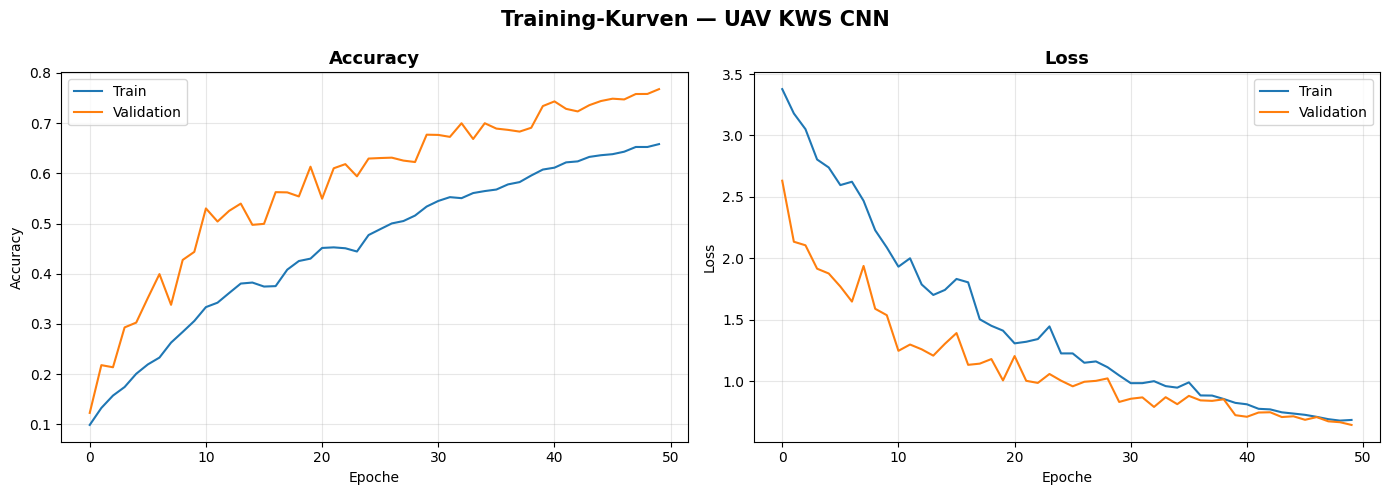

In [10]:
import matplotlib.pyplot as plt

# ── Test-Accuracy ──────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {test_acc * 100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

# ── Training-Kurven ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training-Kurven — UAV KWS CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(results_path / 'model_a_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

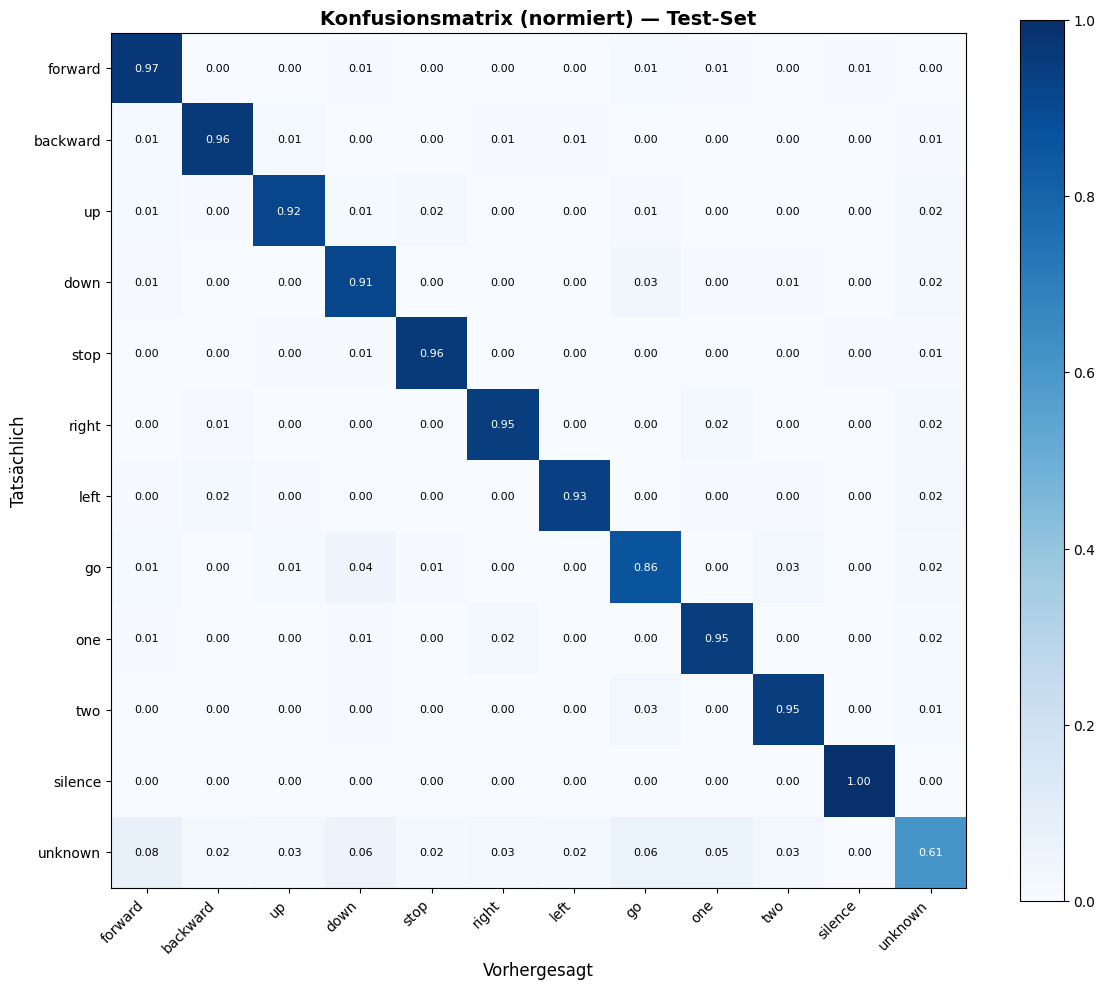

              precision    recall  f1-score   support

     forward       0.32      0.97      0.48       155
    backward       0.62      0.96      0.75       165
          up       0.74      0.92      0.82       425
        down       0.60      0.91      0.72       406
        stop       0.84      0.96      0.90       411
       right       0.76      0.95      0.84       396
        left       0.82      0.93      0.88       412
          go       0.55      0.86      0.67       402
         one       0.63      0.95      0.76       399
         two       0.77      0.95      0.85       424
     silence       0.42      1.00      0.59         5
     unknown       0.97      0.61      0.75      3932

    accuracy                           0.76      7532
   macro avg       0.67      0.91      0.75      7532
weighted avg       0.84      0.76      0.77      7532



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predictions auf Test-Set
y_true, y_pred = [], []
for X_batch, y_batch in test_gen:
    preds = model.predict(X_batch, verbose=0)
    y_true.extend(y_batch)
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ── Konfusionsmatrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(LABELS, fontsize=10)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color=color)

ax.set_title('Konfusionsmatrix (normiert) — Test-Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Vorhergesagt', fontsize=12)
ax.set_ylabel('Tatsächlich', fontsize=12)
plt.tight_layout()
plt.savefig(results_path / 'model_a_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ──────────────────────────────────────────────────
print(classification_report(y_true, y_pred, target_names=LABELS))